> **📝 내 메모** — (여기에 적기. 원본 셀은 건드리지 말고 새 셀로만 추가.)

> **⚙️ Aer 사본 (원본에 없는 셀)** — 이 노트북은 실기기 대신 **로컬 시뮬레이터**로 돕니다.
> IBM 계정·토큰·네트워크가 전혀 필요 없고, 큐 대기도 없습니다. 원본은 옆의
> `1_Demonstrate_Execution_Modes.ipynb` / `2_Demonstrate_Circuit_Running_RealHW.ipynb`.
> 바뀐 셀에는 전부 `[Aer 사본]` 주석이 붙어 있습니다. 커널은 `Python (qiskit-sg24)`.

In [1]:
# --- [Aer 사본] 설정 ---
from qiskit_aer import AerSimulator

# 실기기 대신 로컬 시뮬레이터.
backend = AerSimulator()

# ⚠️ 핵심: transpile 타겟도 반드시 Aer여야 한다.
#    실기기(120~156 qubit)를 타겟으로 잡으면 2-qubit 회로가 그 폭까지 확장되어
#    시뮬레이션이 불가능해진다 (statevector 2^120).

print(f"backend = {backend.name} (로컬 시뮬레이터, 큐 없음)")

backend = aer_simulator (로컬 시뮬레이터, 큐 없음)


# Task 4.2 Demonstrate running Circuits on Real Hardware

**Overview:** This notebook covers how to run circuits on real hardware.

*   **Execution steps** on real hardware.
*   **Primitives:** Sampler, Estimator, their implementations and input/output structure.
*   **Broadcasting rules** how are parameter sets and observables used to compute expectation values efficiently.
*   **Session execution** and how to open, close and view session details.



In [2]:
# Import necessary libraries
from qiskit import QuantumCircuit
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit_ibm_runtime import EstimatorV2 as Estimator
from qiskit_aer import AerSimulator
from qiskit.quantum_info import SparsePauliOp
from qiskit.circuit import Parameter
import numpy as np

print("Libraries imported successfully.")

Libraries imported successfully.


## Objective 1 : Execute on Target Hardware

Executing quantum circuits on real hardware involves several key steps:

1. **Authentication**: Connecting to the IBM Quantum Runtime service
2. **Backend Selection**: Choosing an available quantum processor
3. **Circuit Preparation**: Transpiling circuits for specific hardware constraints
4. **Job Submission**: Sending circuits for execution
5. **Result Retrieval**: Obtain and analyze measurement outcomes

> **[Aer 사본]** 원본에는 여기에 "IBM 크레딧을 소모한다"는 경고가 있다. 로컬 시뮬레이터라 크레딧을 쓰지 않는다.

In [3]:
# Example:  Running a Quantum Circuit on Real Hardware

# --- STEP 1: Authentication ---
# if account is already saved, this will load it
# [Aer 사본] 원본: service = QiskitRuntimeService()
# replace <instance_name> with your instance name
# replace <token> with your IBM Quantum API token
# Uncomment and use the following line if you need to specify instance and token
# srvice = QiskitRuntimeService(channel="ibm_cloud",instance="<instance_name>",token=<token>)

   
# --- STEP 2: Backend Selection ---
# Choose the least busy available backend to minimize queue time with real hardware only
# [Aer 사본] 원본: backend = service.least_busy(operational=True, simulator=False)
backend = AerSimulator()
print(f"Using backend: {backend.name}")
print(f"Backend properties: {backend.num_qubits} qubits (Aer 기본값)")

# --- STEP 3: Circuit Preparation ---
# Create a simple Bell state circuit
qc = QuantumCircuit(2, 2)
qc.h(0)                   
qc.cx(0, 1) 
qc.measure([0, 1], [0, 1])

# Display the circuit
qc.draw('mpl')

# Transpile the circuit for the specific hardware backend
# This transpiles the circuit to the backend's: Native gate set,  Qubit connectivity and Optimization level (0-3, where 3 is most optimized)
pm = generate_preset_pass_manager(backend=backend, optimization_level=3)
transpiled_circuit = pm.run(qc)

# Define the observable we want to measure (ZZ correlation for example)
ZZ = SparsePauliOp.from_list([("ZZ", 1)])

# --- STEP 4: Job Submission ---
# Create an Estimator instance and run the job
estimator = Estimator(mode=backend)

# Map observables to the transpiled circuit layout
observables = [ZZ.apply_layout(transpiled_circuit.layout)]

# Submit the job
job = estimator.run([(transpiled_circuit, observables)])
print(f"\nJob ID: {job.job_id()}")
print("Job submitted successfully! Check the IBM Quantum dashboard for status.")

Using backend: aer_simulator
Backend properties: 29 qubits (Aer 기본값)



Job ID: a9171493-ec42-4edd-b120-a72f47fa84cc
Job submitted successfully! Check the IBM Quantum dashboard for status.


In [4]:
# --- STEP 5: Result Retrieval ---
result = job.result()
print(f"Expectation value: {result[0].data.evs}")

Expectation value: [1.]


## Objective 2: Understanding Primitives

Primitives are foundational quantum computing operations that abstract away hardware-specific details. They provide standardized interfaces for common quantum tasks.

### Primitives:


**1. Sampler**:
- **Used for**: Sampling measurement outcomes from quantum circuits.
- **Output**: Counts or probability distributions.

**2. Estimator**:
- **Used for**: Calculating expectation values of observables.
- **Output**: Expectation value ± standard error.

### Primitive Implementations:

**Base Classes**:
- `BaseSamplerV2` : Base class for sampler, all sampler implementations inherit from this class.
- `BaseEstimatorV2`: Base class for estimator, all estimator implementations inherit from this class.

**V2 Primitives**:
- `SamplerV2`: Latest sampler with enhanced capabilities.
- `EstimatorV2`: Latest estimator with improved performance and features.

**Alternatives**:
- `StateVectorSampler`: Simulator-based sampler.
- `StateVectorEstimator`: Simulator-based estimator using state vector simulation.
- `BackendSamplerV2`: Backend-specific sampler optimizations.
- `BackendEstimatorV2`: Backend-specific estimator optimizations.


> **[Aer 사본]** 원본에는 여기에 "IBM 크레딧을 소모한다"는 경고가 있다. 로컬 시뮬레이터라 크레딧을 쓰지 않는다.

In [5]:
# Example: Using the Sampler Primitive 
# The Sampler primitive executes quantum circuits and returns measurement statistics.

# Create a Sampler instance connected to our backend
sampler = Sampler(mode=backend)

# The 'shots' parameter determines how many times to execute the circuit
shots = 1024

# Submit the sampling job with the transpiler bell state circuit
job = sampler.run([transpiled_circuit], shots=shots)

print(f"Sampler Job ID: {job.job_id()}")
print(f"Requested shots: {shots}")

Sampler Job ID: 10aaa18b-9f12-4652-ba79-eb625067f4ec
Requested shots: 1024


In [6]:
# To retrieve results:
result = job.result()
counts = result[0].data.c.get_counts()
print(f"\nMeasurement counts: {counts}")


Measurement counts: {'00': 545, '11': 479}


## Objective 3: Primitive Inputs and Outputs

### Inputs

#### Sampler Input Structure

Each Sampler **Pub** (Primitive Unified Bloc) accepts:
1. **Quantum Circuit**: The circuit to execute (should include measurements for qubits that will be sampled).
2. **Parameters**: Parameter values for parameterized circuits (needed only if the circuit is parameterized).
3. **Shots**: Number of circuit executions (optional).

#### Estimator Input Structure

Each Estimator **Pub**  accepts:
1. **Quantum Circuit**: The circuit to execute (must be transpiled for the target backend).
2. **Observables**: One or more observables to measure (as `Pauli`, `SparsePauliOp`, `PauliList` or `str` objects).
3. **Parameters**: Parameter values for parameterized circuits (optional).
4. **Precision**: Target precision for error mitigation (optional).



> **[Aer 사본]** 원본에는 여기에 "IBM 크레딧을 소모한다"는 경고가 있다. 로컬 시뮬레이터라 크레딧을 쓰지 않는다.

In [7]:
# Example 1: Using the Estimator Primitive with Multiple Parameters and Observables
# --- Create a parameterized circuit ---
circuit = QuantumCircuit(2)
circuit.h(0)                     
circuit.cx(0, 1)                 
circuit.ry(Parameter("a"), 0)    # Parameterized rotation Y
circuit.rz(Parameter("b"), 0)    # Parameterized rotation Z
circuit.cx(0, 1)                 
circuit.h(0)

# Display the parameterized circuit
print("Parameterized Circuit:")
circuit.draw('mpl')

# --- Transpile for hardware ---
pm = generate_preset_pass_manager(optimization_level=1, backend=backend)
transpiled_circuit = pm.run(circuit)
layout = transpiled_circuit.layout

# --- Define parameter sweep ---
# Create 100 different parameter combinations
# Shape: (100, 2) where 100 is number of parameter sets, 2 is parameters per set
params = np.vstack([
    np.linspace(-np.pi, np.pi, 100),        # Parameter 'a' values
    np.linspace(-4 * np.pi, 4 * np.pi, 100) # Parameter 'b' values
]).T

print(f"\nParameter array shape: {params.shape}")
print(f"First 5 parameter sets:\n{params[:5]}")

# --- Define multiple observables ---
# measure three different observables for each parameter set
# Shape: (3, 1) where 3 is number of observable sets, 1 is observables per set
observables = [
    [SparsePauliOp(["XX", "IY"], [0.5, 0.5])],   # Linear combination of XX and IY
    [SparsePauliOp("XX")],                       # XX
    [SparsePauliOp("IY")],                       # IY
]

# Apply the same layout as the transpiled circuit
observables = [
    [observable.apply_layout(layout) for observable in observable_set]
    for observable_set in observables
]

print(f"\nNumber of observable sets: {len(observables)}")
print(f"Observables per set: {len(observables[0])}")

# --- Create the Estimator Pub ---
# Total calculations: 1 circuit  × 3 observables × 100 parameter sets = 300 expectation values
estimator_pub = (transpiled_circuit, observables, params)

# --- Execute with Estimator ---
estimator = Estimator(mode=backend)
job = estimator.run([estimator_pub])

print(f"\nJob submitted! Job ID: {job.job_id()}")

Parameterized Circuit:

Parameter array shape: (100, 2)
First 5 parameter sets:
[[ -3.14159265 -12.56637061]
 [ -3.07812614 -12.31250454]
 [ -3.01465962 -12.05863847]
 [ -2.9511931  -11.8047724 ]
 [ -2.88772658 -11.55090632]]

Number of observable sets: 3
Observables per set: 1

Job submitted! Job ID: 7d7d9e38-2504-42ff-96c3-68ee49717bef


In [8]:
# --- Process Results ---
result = job.result()
print(f"\nResult shape: {result[0].data.evs.shape}")  # Should be (3, 100)
print(f"First expectation values: {result[0].data.evs[:, :5]}")


Result shape: (3, 100)
First expectation values: [[ 0.01513672  0.15893555  0.30615234  0.44360352  0.53222656]
 [ 0.04101562  0.08203125  0.12060547  0.18603516  0.23242188]
 [-0.01074219  0.23583984  0.49169922  0.70117188  0.83203125]]


#### Broadcasting Rules

Broadcasting allows you to efficiently compute expectation values for multiple parameter sets and observables in a single primitive call. The rules follow NumPy broadcasting conventions.

- Input arrays do not need to have the same number of dimensions.
   - The resulting array will have the same number of dimensions as the input array with the largest dimension.
   - The size of each dimension is the largest size of the corresponding dimension.
   - Missing dimensions are assumed to have size one.
- Shape comparisons start with the rightmost dimension and continue to the left.
- Two dimensions are compatible if their sizes are equal or if one of them is 1.


In Qiskit
- Parameter values are provided as n × m arrays
- Observables are provided as k × 1 arrays

They are then both combined according to standard broadcasting rules

##### Examples

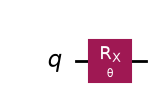

In [9]:
simulator = AerSimulator()

# Parameterized 1-qubit circuit
theta = Parameter("θ")
qc = QuantumCircuit(1)
qc.rx(theta, 0)

# Estimator primitive
estimator = Estimator(mode=simulator)

pm = generate_preset_pass_manager(optimization_level=1, backend=simulator)
transpiled_circuit = pm.run(qc)
transpiled_circuit.draw('mpl')

In [10]:
# Broadcasting Example 1: Single observable and parameter set
# Parameter values:   (5 × 1)
# Observables:        (1 × 1)
#--------------------------------
# Output:             (5 × 1)

parameter_values = [[v] for v in np.linspace(0, np.pi, 5)]
observable = SparsePauliOp("Z")
estimator_pub = (transpiled_circuit, observable, parameter_values)
job = estimator.run([estimator_pub])
result = job.result()
print(result[0].data.evs)
print(f"Output shape: {result[0].data.evs.shape}")

[ 1.00000000e+00  6.88964844e-01 -9.76562500e-04 -7.12402344e-01
 -1.00000000e+00]
Output shape: (5,)


In [11]:
# Broadcasting Example 2: Zip Parameters and Observables
# Parameter values:   (5 × 1)
# Observables:        (5 × 1)
#--------------------------------
# Output:             (5 × 1)

parameter_values = [[v] for v in np.linspace(0, np.pi, 5)]

observables = [
    SparsePauliOp("Z"),
    SparsePauliOp("X"),
    SparsePauliOp("Y"),
    SparsePauliOp("Z"),
    SparsePauliOp("X"),
]

estimator_pub = (transpiled_circuit, observables, parameter_values)
job = estimator.run([estimator_pub])
result = job.result()
print(result[0].data.evs)
print(f"Output shape: {result[0].data.evs.shape}")

[ 1.          0.01904297 -1.         -0.70410156 -0.02636719]
Output shape: (5,)


In [12]:
# Broadcasting Example 3: Outer Product (Full Broadcast)
# Parameter values:   (1 × 6)
# Observables:        (4 × 1)
#--------------------------------
# Output:             (4 × 6)

parameter_values = [np.linspace(0, np.pi, 6).tolist()]

observables = [
    [SparsePauliOp("Z")],
    [SparsePauliOp("X")],
    [SparsePauliOp("Y")],
    [SparsePauliOp("I")],
]


estimator_pub = (transpiled_circuit, observables, parameter_values)
job = estimator.run([estimator_pub])
result = job.result()
print(result[0].data.evs)
print(f"Output shape: {result[0].data.evs.shape}")

[[ 1.00000000e+00  8.01757812e-01  3.37890625e-01 -3.35937500e-01
  -8.19335938e-01 -1.00000000e+00]
 [ 1.70898438e-02 -2.92968750e-03 -6.34765625e-03 -2.78320312e-02
  -1.85546875e-02  2.97851562e-02]
 [ 9.76562500e-04 -6.16699219e-01 -9.54589844e-01 -9.54589844e-01
  -5.94726562e-01 -3.90625000e-03]
 [ 1.00000000e+00  1.00000000e+00  1.00000000e+00  1.00000000e+00
   1.00000000e+00  1.00000000e+00]]
Output shape: (4, 6)


In [13]:
# Broadcasting Example 4: N-D Generalization (Multiple Observable Arrays)
# Parameter values:   (3 × 6)
# 2 Observables:      (3 × 1)
#--------------------------------
# Output:             2 * (3 × 6)
parameter_values = [
    np.linspace(0, np.pi, 6).tolist(),
    np.linspace(np.pi, 2*np.pi, 6).tolist(),
    np.linspace(2*np.pi, 3*np.pi,6).tolist(),
]

observables_a = [
    [SparsePauliOp("Z")],
    [SparsePauliOp("X")],
    [SparsePauliOp("Y")],
]

observables_b = [
    [SparsePauliOp("X")],
    [SparsePauliOp("Y")],
    [SparsePauliOp("Z")],
]

estimator_pub = (transpiled_circuit, [observables_a, observables_b], parameter_values)

job = estimator.run([estimator_pub])
result = job.result()
print(result[0].data.evs)
print(f"Output shape: {result[0].data.evs.shape}")

[[[ 1.00000000e+00  8.06640625e-01  3.05175781e-01 -3.08593750e-01
   -8.11035156e-01 -1.00000000e+00]
  [-2.44140625e-03  4.54101562e-02  1.95312500e-03 -4.88281250e-03
    1.46484375e-03  4.39453125e-03]
  [-3.41796875e-03 -5.72753906e-01 -9.56542969e-01 -9.49218750e-01
   -5.83496094e-01 -1.61132812e-02]]

 [[-7.32421875e-03  8.30078125e-03  1.12304688e-02  7.32421875e-03
   -1.85546875e-02  4.88281250e-04]
  [ 2.44140625e-03  5.99121094e-01  9.50195312e-01  9.47753906e-01
    5.93750000e-01 -7.81250000e-03]
  [ 1.00000000e+00  8.11523438e-01  2.95898438e-01 -3.19824219e-01
   -8.20800781e-01 -1.00000000e+00]]]
Output shape: (2, 3, 6)


### Outputs


the data returned from the result object is a `PubResult` list, each element in this list corresponds to each PUB submitted as an input to the primitive `run` method.

#### Sampler Output Structure:

```
└── PrimitiveResult
    ├── PubResult[0]
    │   ├── metadata
    │   └── data  ## In the form of a DataBin object
    │       ├── NAME_OF_CLASSICAL_REGISTER
    │       │   └── BitArray of count data (default is 'meas')
    |       |
    │       └── NAME_OF_ANOTHER_CLASSICAL_REGISTER
    │           └── BitArray of count data (exists only if more than one
    |                 ClassicalRegister was specified in the circuit)
    ├── PubResult[1]
    |   ├── metadata
    |   └── data  ## In the form of a DataBin object
    |       └── NAME_OF_CLASSICAL_REGISTER
    |           └── BitArray of count data for second pub
    ├── ...
    ├── ...
    └── ...
```

##### Estimator Output Structure:

```
└── PrimitiveResult
    ├── PubResult[0]
    │   ├── metadata
    │   └── data  ## In the form of a DataBin object
    │       ├── evs
    │       │   └── List of estimated expectation values in the shape
    |       |         specified by the first pub
    │       └── stds
    │           └── List of calculated standard deviations in the
    |                 same shape as above
    ├── PubResult[1]
    |   ├── metadata
    |   └── data  ## In the form of a DataBin object
    |       ├── evs
    |       │   └── List of estimated expectation values in the shape
    |       |        specified by the second pub
    |       └── stds
    |           └── List of calculated standard deviations in the
    |                same shape as above
    ├── ...
    ├── ...
    └── ...
```

> **[Aer 사본]** 원본에는 여기에 "IBM 크레딧을 소모한다"는 경고가 있다. 로컬 시뮬레이터라 크레딧을 쓰지 않는다.

In [14]:
# Example 2: Processing Results
# --- Create a 10-qubit GHZ circuit ---
# GHZ states are maximally entangled states: (|0...0⟩ + |1...1⟩)/√2
circuit = QuantumCircuit(10)
circuit.h(0)                        
circuit.cx(range(0, 9), range(1, 10)) 
circuit.measure_all()                

print("GHZ State Circuit (10 qubits):")
circuit.draw('mpl', fold=-1)  # Don't fold the circuit display

# --- Transpile for hardware ---
transpiled_circuit = pm.run(circuit)
sampler_pub = [transpiled_circuit]
# --- Execute with Sampler ---
sampler = Sampler(mode=backend)
job = sampler.run(sampler_pub, shots=1000)
print(f"Sampler Job ID: {job.job_id()}")

GHZ State Circuit (10 qubits):
Sampler Job ID: 069dfee6-8d3a-4493-bf11-9163c9f4aad6


In [15]:
result = job.result()

print("\n=== SAMPLER RESULTS ANALYSIS ===\n")

# 1. Access the data bin
data = result[0].data
print(f"DataBin contents: {data}")
print(f"Available registers: {list(data.keys())}\n")

# 2. Access the BitArray
# 'meas' is the default classical register name created by measure_all()
bit_array = data.meas
print(f"BitArray type: {type(bit_array)}")
print(f"BitArray shape: {bit_array.array.shape}")

# 3. View raw measurement data
for i in range(min(10, bit_array.array.shape[0])):
    print(f"   Shot {i}: {bit_array.array[i]}")

# 4. Convert to counts dictionary
counts = bit_array.get_counts()
sorted_counts = sorted(counts.items(), key=lambda x: x[1], reverse=True)
print(f"\nMeasurement counts (all outcomes):")
for outcome, count in sorted_counts:
    print(f"   {outcome}: {count} shots ({count/1000*100:.1f}%)")


=== SAMPLER RESULTS ANALYSIS ===

DataBin contents: DataBin(meas=BitArray(<shape=(), num_shots=1000, num_bits=10>))
Available registers: ['meas']

BitArray type: <class 'qiskit.primitives.containers.bit_array.BitArray'>
BitArray shape: (1000, 2)
   Shot 0: [  3 255]
   Shot 1: [  3 255]
   Shot 2: [  3 255]
   Shot 3: [  3 255]
   Shot 4: [  3 255]
   Shot 5: [0 0]
   Shot 6: [0 0]
   Shot 7: [  3 255]
   Shot 8: [0 0]
   Shot 9: [  3 255]

Measurement counts (all outcomes):
   0000000000: 521 shots (52.1%)
   1111111111: 479 shots (47.9%)


In [16]:
# optionally, convert away from the native BitArray format to a dictionary format
counts = data.meas.get_counts()
print(f"Counts: {counts}")

Counts: {'1111111111': 479, '0000000000': 521}


## Objective 4 : Run Job sessions

Sessions provide an efficient way to run multiple related jobs on the same quantum hardware. They maintain context between jobs, which can reduce overhead and improve performance for iterative algorithms.


A **Session** is a context that:
1. **Reserves hardware time** for multiple jobs
2. **Maintains circuit context** between jobs
3. **Reduces overhead** for iterative algorithms
4. **Ensures consistent hardware conditions** for related jobs

**Session Lifecycle:**
1. **Open**: Create a session with a specific backend
2. **Use**: Run multiple jobs within the session
3. **Close**: Explicitly close or let timeout

**Key Parameters:**
- **TTL (Time To Live)**: Maximum session duration (default: 8 hours)
- **Max Time**: Maximum job execution time within session


<span style="color:red"> **Note:Open plan users can not run job in session execution mode, The following code blocks in the rest of the notebook will fail if you have an open plan.** </span>

### Open a session

Can be done by initializing the `Session` class or by using Context Manager `with Session()`.

In [17]:
from qiskit_ibm_runtime import (
    Session,
    SamplerV2 as Sampler,
    EstimatorV2 as Estimator,
)

session = Session(backend=backend)
estimator = Estimator(mode=session)
sampler = Sampler(mode=session)
# Close the session because no context manager was used.
session.close()

In [18]:
from qiskit_ibm_runtime import (
    Session,
    SamplerV2 as Sampler,
    EstimatorV2 as Estimator,
)
 
# [Aer 사본] 원본: backend = service.least_busy(operational=True, simulator=False)
backend = AerSimulator()
with Session(backend=backend):
    estimator = Estimator()
    sampler = Sampler()

### Session Length




Similar to `Batch`, A session max TTL can be defined with `max_time`, it starts when the session starts, when max time is reached , the session is closed and any job running will finish but all queued jobs will fail.

| Plan Type | Maximum Job Duration |
|-----------|-----------------------|
| Premium Plans | 8 hours |

Additionlly there is also interactive TTL can not be configured (1 minute), if there is no session jobs on the queue within the window, the session is temporarliy deactivated.

### End a session

A session is closed when any of the following happens:

* TTL is reached.
* session is manually canceled or closed using `session.close()`.
* session is used in a context manager , automatically closed when the context ends.

When a session is closed. it no longer accepts jobs, however the already submitted jobs will be executed.


In [19]:
session = Session(backend=backend)
 
estimator = Estimator(mode=session)
sampler = Sampler(mode=session)
job1 = estimator.run([estimator_pub])
job2 = sampler.run([sampler_pub])
print(f"Result1: {job1.result()}")
print(f"Result2: {job2.result()}")
 
# Manually close the session. Running and queued jobs will run to completion.
session.close()

Result1: PrimitiveResult([PubResult(data=DataBin(evs=np.ndarray(<shape=(2, 3, 6), dtype=float64>), stds=np.ndarray(<shape=(2, 3, 6), dtype=float64>), shape=(2, 3, 6)), metadata={'target_precision': 0.015625, 'shots': 4096, 'circuit_metadata': {}})], metadata={'version': 2})
Result2: PrimitiveResult([SamplerPubResult(data=DataBin(meas=BitArray(<shape=(), num_shots=1024, num_bits=10>)), metadata={'shots': 1024, 'circuit_metadata': {}})], metadata={'version': 2})


### Check Session status

Use <code>session.status()</code> to check the session status, it can be one of the following:

* Pending
* In Progress, accepting new jobs
* In Progress, not accepting new jobs : submitted jobs will be completed, and session will be closed after that
* Closed

### Determine Session details

In [20]:
from qiskit_ibm_runtime import (
    QiskitRuntimeService,
    Session,
    EstimatorV2 as Estimator,
)
  
with Session(backend=backend) as session:
    print(session.details())

None


### Usage Patterns

Sessions are most useful for algorithms that requitr communication between classical and quantum resources.
for example

* Run iterative workload that uses SCiPy to minimize cost function.
* Run VQE algorithms in sessions.

---
## Summary
---

In this notebook, we covered:

## Demonstrate running circuits on Real Hardware:

1. **Execution on real hardware** involves authentication, backend selection, circuit preparation, job submission and results retrieval.
2. **Qiskit runtime primitives** are standard interfaces that abstract hardware specific details.
3. **Sampler** returns the measurments or counts of a circuit while Estimator return the expectation values of observables.
4. **Broadcasting rules** are used to compute expected values for different groups of observables and paramater values.
5. **Session mode** gives execlusive QPU access, and it best used with iterative workflows that requries classical and quantum information.


---

## Practice Questions

---

**1) Consider the following code that creates a batch with specific time limits**

```
from qiskit_ibm_runtime import Batch, SamplerV2 as Sampler

# Create a batch with 30 minute max_time
with Batch(backend=backend, max_time="30m") as batch:
    sampler = Sampler()
    
    # Submit first job immediately
    job1 = sampler.run([circuit1], shots=1000)
    print(f"Job1 submitted at: {datetime.now()}")
    
    # Wait 2 minutes before submitting second job
    time.sleep(120)
    job2 = sampler.run([circuit2], shots=1000)
    print(f"Job2 submitted at: {datetime.now()}")
    
    # Get results
    result1 = job1.result()
    result2 = job2.result()
```

Which statement is correct?

A) The max_time="30m" parameter means the batch will stay open for exactly 30 minutes from creation, regardless of job activity.

B) If no jobs are submitted for 1 minute after job2 completes, the batch will enter a "temporarily deactivated" state due to the interactive TTL.

C) The interactive TTL (1 minute) is configurable and can be extended using an additional parameter like interactive_ttl="5m".

D) If job2 takes 29 minutes to complete, the batch will immediately close when finished, even though 1 minute remains of the 30-minute max_time.

**Answer:**
<details> <br/>

B) If no jobs are submitted for 1 minute after job2 completes, the batch will enter a "temporarily deactivated" state due to the interactive TTL.

</details>

---

**2)In which scenario is session mode most appropriate?**

A) Iterative workloads where results from one job influence the next.

B) Submitting many independent jobs with no shared context.

C) Running a single circuit once.

D) When minimizing cost is the top priority.

**Answer:**
<details> <br/>
A) Iterative workloads where results from one job influence the next.

Session mode is designed for iterative or interactive workloads.
</details>

---

**3)What broadcasting rule is applied in the following example**

```
params = [[0.1], [0.2], [0.3]]

observables = [
    SparsePauliOp("Z"),
    SparsePauliOp("X"),
    SparsePauliOp("Y"),
]

job = estimator.run([{transpiled_qc,observables,params,}])
```

A) Single-observable broadcast

B) Outer product broadcast

C) Zip

D) Invalid input — raises an error

**Answer:**
<details> <br/>
C) Zip

Both lists have length 3*1, Qiskit applies zip broadcasting
</details>

---

**4)Which of the following code patterns demonstrates the recommended way to use Session mode for an iterative algorithm?**

```
# Pattern A
session = Session(backend=backend)
estimator = Estimator(mode=session)
for i in range(10):
    job = estimator.run([(circuit, observables, params[i])])
    result = job.result()
    # Process result and update params
session.close()

# Pattern B
with Session(backend=backend) as session:
    estimator = Estimator()
    for i in range(10):
        job = estimator.run([(circuit, observables, params[i])])
        result = job.result()
        # Process result and update params

# Pattern C
jobs = []
for i in range(10):
    session = Session(backend=backend)
    estimator = Estimator(mode=session)
    job = estimator.run([(circuit, observables, params[i])])
    jobs.append(job)
    session.close()
results = [job.result() for job in jobs]
```

Which pattern is most efficient and follows best practices?

A) Pattern A - Explicit session creation and closure

B) Pattern B - Using a context manager (with statement)

C) Pattern C - Creating a new session for each iteration

D) All patterns are equally good

**Answer:**
<details> <br/>
B) Pattern B - Using a context manager 

Context manager automatically handles session cleanup (closing) when the block exits, even if an error occurs
</details>

---